# Motion Segment ZV Comparison

This notebook runs pyshoe-based zero-velocity detection on the previously segmented motion bouts, then compares the reconstructed trajectory and traveled distance against the synced OptiTrack ankle marker.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

for candidate in [
    Path.cwd().resolve(),
    Path.cwd().resolve() / "pyshoe_CSH",
    Path.cwd().resolve().parent / "pyshoe_CSH",
    Path("/home/user/soccer_analysis/pyshoe_CSH"),
]:
    if (candidate / "ins_tools").exists():
        NOTEBOOK_DIR = candidate
        break
else:
    raise FileNotFoundError("Could not locate pyshoe_CSH from the current working directory.")

PROJECT_ROOT = NOTEBOOK_DIR.parent
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

DATASET_NAME = "0324_17_20"
DATA_DIR = PROJECT_ROOT / "data" / "optitrack_imu" / DATASET_NAME
SEGMENTS_DIR = DATA_DIR / "straight_walk_segments"
SUMMARY_PATH = DATA_DIR / "straight_walk_segments_summary.csv"
# ATTITUDE_SOURCE = "gyro_integrated"
ATTITUDE_SOURCE = "measured_quat"
# ACC_SOURCE = "raw_acc"
ACC_SOURCE = "linear_acc"
QUAT_MODE = "direct"
RESULTS_DIR = NOTEBOOK_DIR / "results" / f"segment_zv_compare_{DATASET_NAME}_{ATTITUDE_SOURCE}_{ACC_SOURCE}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DETECTOR_GRIDS = {
    "shoe": np.geomspace(1e4, 3e7, 12),
    "ared": np.linspace(0.1, 4.0, 12),
}
WINDOW_SIZE = 5
SIGMA_A = 0.01
SIGMA_W_DPS = 0.1
ALIGN_DIST_M = 0.8
TIME_COLUMN = "time_synced_to_imu"

print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"ATTITUDE_SOURCE: {ATTITUDE_SOURCE}, QUAT_MODE: {QUAT_MODE}, ACC_SOURCE: {ACC_SOURCE}")


DATA_DIR: /home/user/soccer_analysis/data/optitrack_imu/0324_17_20
RESULTS_DIR: /home/user/soccer_analysis/pyshoe_CSH/results/segment_zv_compare_0324_17_20_measured_quat_linear_acc
ATTITUDE_SOURCE: measured_quat, QUAT_MODE: direct, ACC_SOURCE: linear_acc


In [2]:
from segment_zv_compare import (
    analyze_segment,
    discover_segments,
    export_best_run_details,
    plot_all_segment_overlays,
    plot_metric_summary,
    plot_segment_detail,
    select_best_per_segment,
    summarize_best_results,
    sweep_all_segments,
)


In [3]:
segment_table = discover_segments(SUMMARY_PATH, SEGMENTS_DIR)
metrics_df = sweep_all_segments(
    segment_table=segment_table,
    detector_grids=DETECTOR_GRIDS,
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
    acc_source=ACC_SOURCE,
)
metrics_df["abs_path_xz_error_m"] = metrics_df["path_xz_error_m"].abs()
metrics_df["abs_disp_xz_error_m"] = metrics_df["disp_xz_error_m"].abs()

#best_df = select_best_per_segment(metrics_df, metric="armse_2d_m")
best_df = select_best_per_segment(metrics_df, metric="path_xz_error_m")
summary_df = summarize_best_results(best_df)

metrics_df.to_csv(RESULTS_DIR / "threshold_sweep.csv", index=False)
best_df.to_csv(RESULTS_DIR / "best_segment_metrics.csv", index=False)
export_best_run_details(
    best_df=best_df,
    segment_table=segment_table,
    output_dir=RESULTS_DIR / "best_run_details",
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
    acc_source=ACC_SOURCE,
)

display(
    best_df[
        [
            "segment_id",
            "direction_label",
            "detector",
            "threshold",
            "armse_2d_m",
            "endpoint_xz_error_m",
            "est_path_xz_m",
            "gt_path_xz_m",
            "path_xz_error_m",
            "zv_ratio",
        ]
    ].round(3)
)
display(summary_df.round(3))


,segment_id,direction_label,detector,threshold,armse_2d_m,endpoint_xz_error_m,est_path_xz_m,gt_path_xz_m,path_xz_error_m,zv_ratio
0,1,axis_1_positive,shoe,10000.000,0.257,0.891,1.857,2.074,-0.218,0.156
1,2,axis_2_positive,shoe,88778.090,0.158,0.452,2.695,2.728,-0.033,0.382
2,3,axis_1_negative,shoe,10000.000,0.341,1.222,2.027,2.102,-0.075,0.239
3,4,axis_2_negative,shoe,10000.000,0.348,1.265,2.431,2.664,-0.233,0.213
4,5,axis_1_positive,ared,0.100,0.193,0.921,2.147,2.131,0.017,0.278
5,6,axis_2_positive,shoe,10000.000,0.292,1.007,2.633,2.702,-0.070,0.158
6,7,axis_1_negative,ared,0.100,0.058,0.128,2.263,2.116,0.148,0.308
7,8,axis_2_negative,shoe,10000.000,0.205,0.615,2.564,2.726,-0.162,0.103
8,9,axis_1_positive,shoe,10000.000,0.237,0.972,2.053,2.122,-0.069,0.232
9,10,axis_2_positive,ared,0.100,0.043,0.096,2.535,2.536,-0.000,0.310


,num_segments,mean_armse_2d_m,mean_armse_xz_m,median_armse_2d_m,median_armse_xz_m,mean_endpoint_xy_error_m,mean_endpoint_xz_error_m,mean_abs_path_xy_error_m,mean_abs_path_xz_error_m,mean_abs_disp_xy_error_m,mean_abs_disp_xz_error_m,count_shoe,count_ared
0,29,0.18,0.18,0.181,0.181,0.631,0.631,0.095,0.095,0.568,0.568,21,8


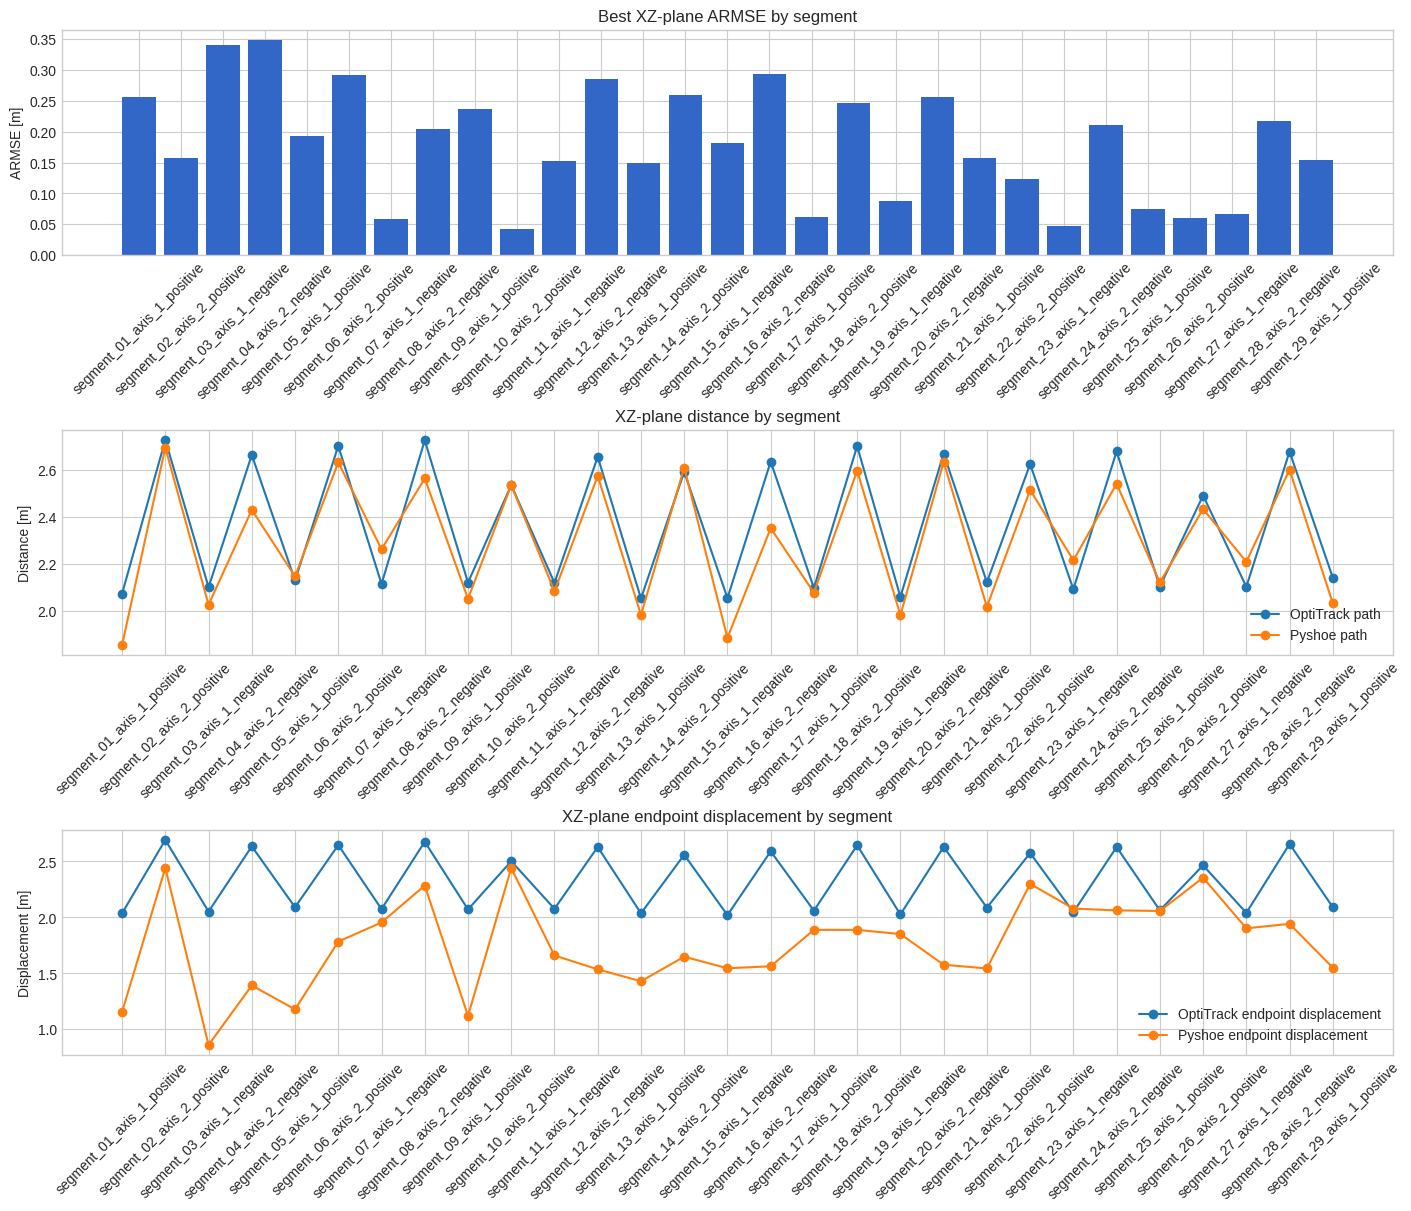

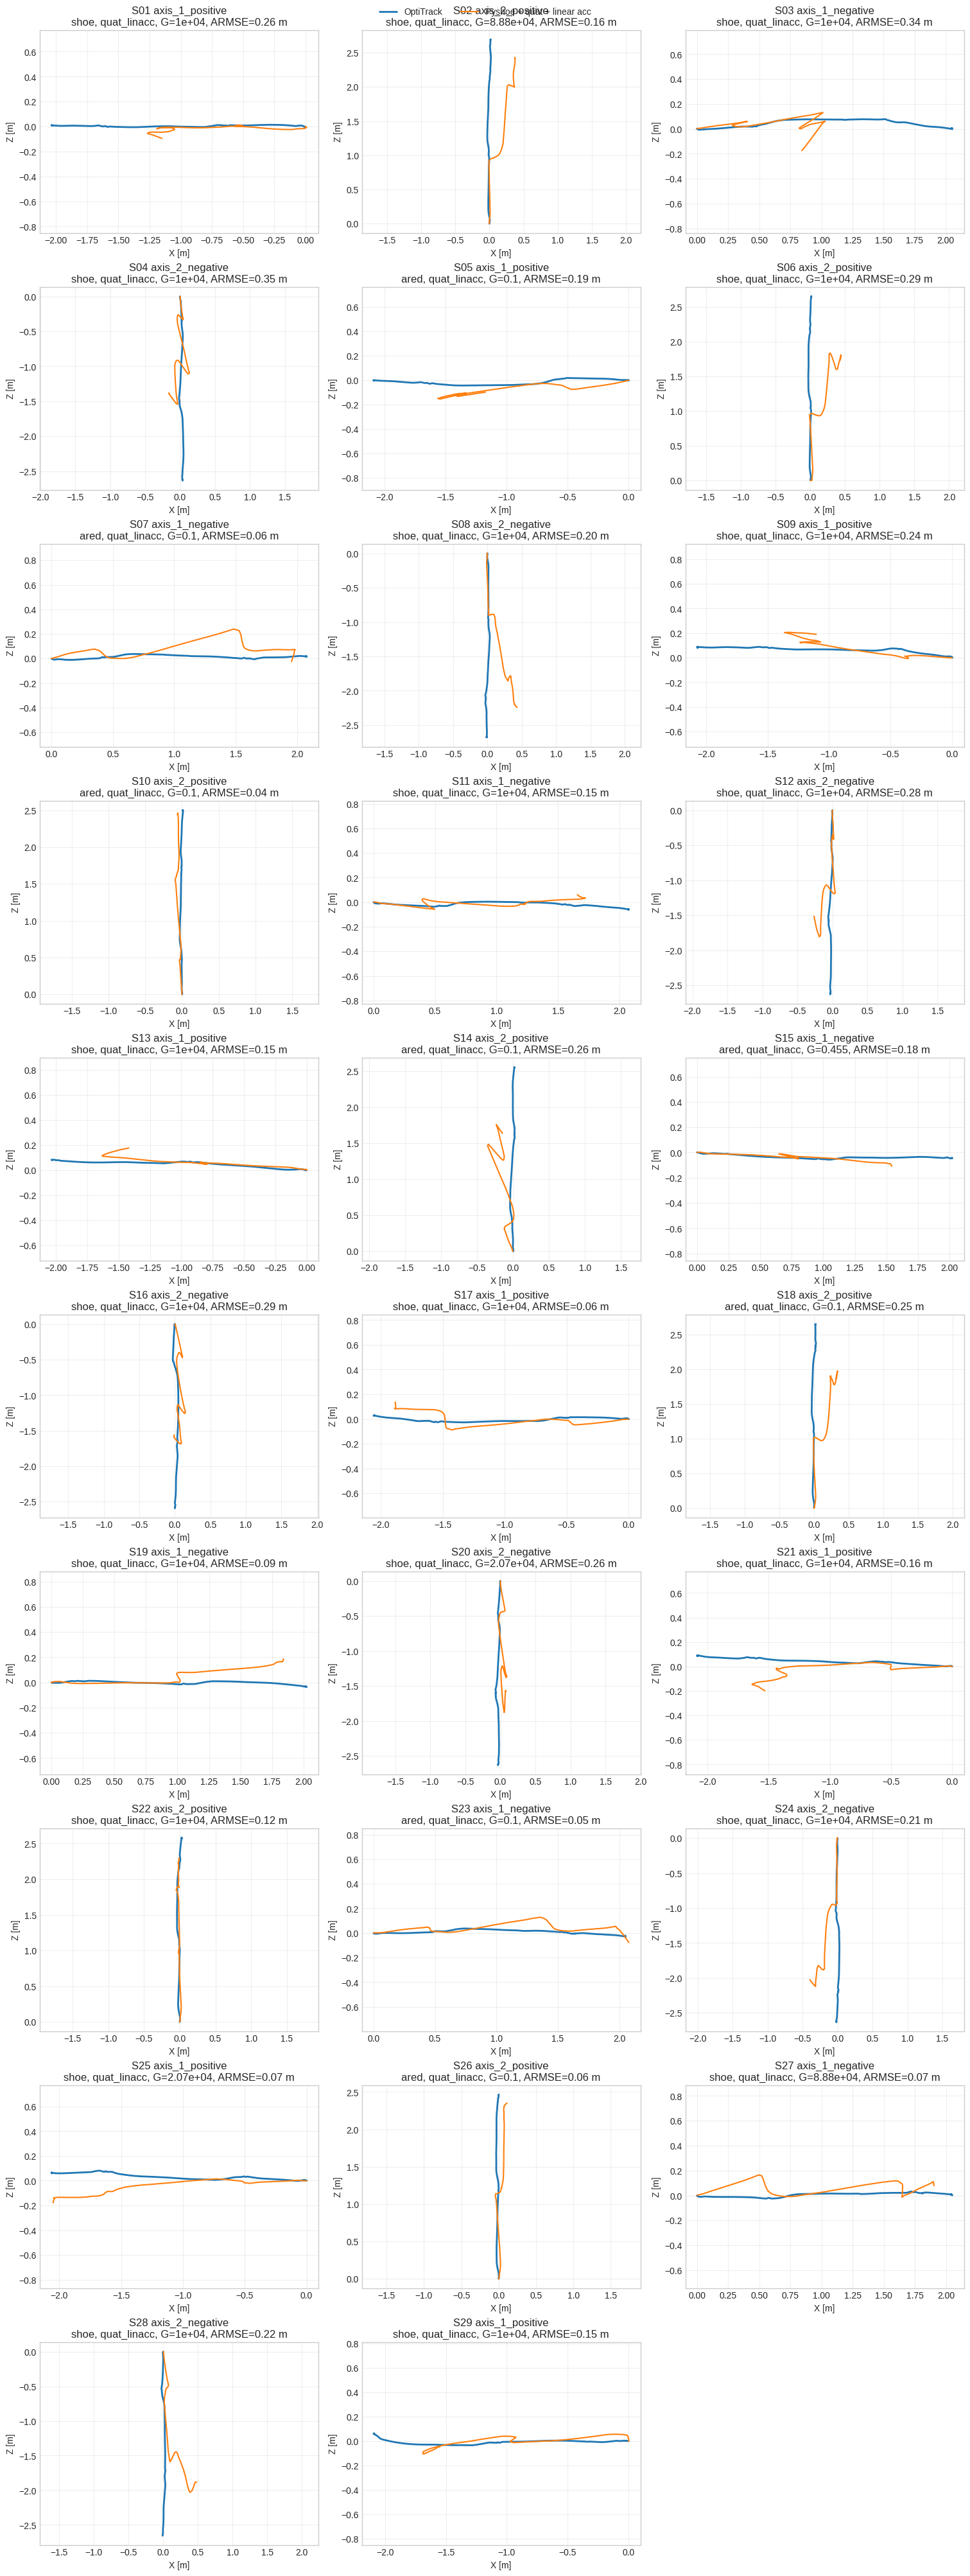

In [4]:
fig, axes = plot_metric_summary(best_df)
plt.show()

fig, axes = plot_all_segment_overlays(
    best_df=best_df,
    segment_table=segment_table,
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    cols=3,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
    acc_source=ACC_SOURCE,
)
plt.show()


,segment_id,direction_label,segment_name,detector,threshold,attitude_source,quat_mode,acc_source,num_samples,duration_s,...,path_xz_error_m,est_disp_xy_m,gt_disp_xy_m,disp_xy_error_m,est_disp_xz_m,gt_disp_xz_m,disp_xz_error_m,est_path_3d_m,gt_path_3d_m,path_3d_error_m
0,3,axis_1_negative,segment_03_axis_1_negative,shoe,10000.0,measured_quat,direct,linear_acc,447,4.62,...,-0.075,0.861,2.052,-1.191,0.861,2.052,-1.191,2.176,2.162,0.014


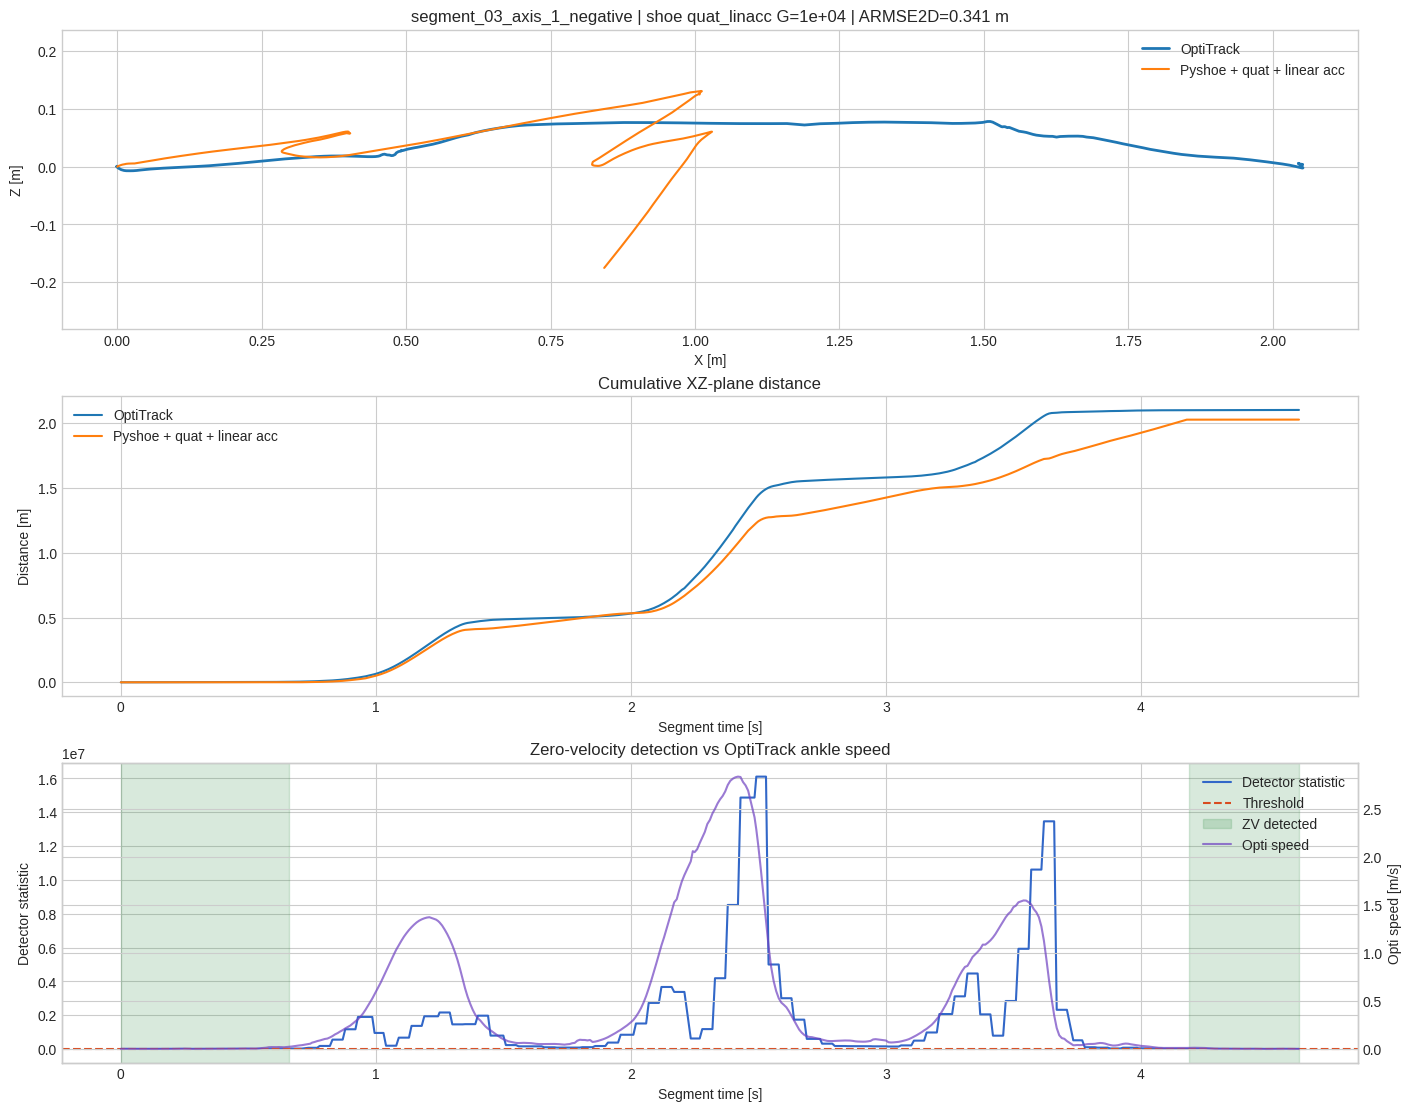

,segment_time_s,imu_time,lrt,zv_detected,opti_speed_mps,est_x_m,est_y_m,est_z_m,est_x_aligned_m,est_y_aligned_m,est_z_aligned_m,gt_x_m,gt_y_m,gt_z_m,est_cumdist_xy_m,gt_cumdist_xy_m,est_cumdist_xz_m,gt_cumdist_xz_m,est_cumdist_3d_m,gt_cumdist_3d_m
0,0.00,24.54,630.319194,1,0.004007,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.01,24.55,630.319194,1,0.004566,-0.000001,-2.604434e-07,-0.000004,1.985240e-06,-2.604434e-07,-0.000004,-0.000034,-0.000027,0.000006,0.000004,0.000035,0.000004,0.000035,0.000004,0.000044
2,0.02,24.56,630.319194,1,0.004569,-0.000006,-1.250433e-06,-0.000008,9.406787e-07,-1.250433e-06,-0.000010,-0.000037,-0.000049,0.000010,0.000010,0.000040,0.000010,0.000040,0.000011,0.000067
3,0.03,24.57,630.319194,1,0.003935,-0.000011,-2.290119e-06,-0.000012,-1.106134e-06,-2.290119e-06,-0.000016,-0.000077,-0.000060,0.000020,0.000017,0.000081,0.000017,0.000081,0.000017,0.000109
4,0.04,24.58,630.319194,1,0.003598,-0.000021,-2.191213e-06,-0.000016,-5.617378e-06,-2.191213e-06,-0.000025,-0.000109,-0.000084,0.000032,0.000027,0.000115,0.000027,0.000115,0.000028,0.000150


In [5]:
SEGMENT_TO_PLOT = 3

selected_metrics = best_df.loc[best_df["segment_id"] == SEGMENT_TO_PLOT].iloc[0]
selected_segment = segment_table.loc[segment_table["segment_id"] == SEGMENT_TO_PLOT].iloc[0]

selected_metrics_dict, selected_detail_df = analyze_segment(
    imu_path=selected_segment["imu_path"],
    opti_path=selected_segment["opti_path"],
    segment_id=int(selected_metrics["segment_id"]),
    direction_label=selected_metrics["direction_label"],
    detector=selected_metrics["detector"],
    threshold=float(selected_metrics["threshold"]),
    window_size=WINDOW_SIZE,
    sigma_a=SIGMA_A,
    sigma_w_dps=SIGMA_W_DPS,
    align_dist_m=ALIGN_DIST_M,
    time_column=TIME_COLUMN,
    attitude_source=ATTITUDE_SOURCE,
    quat_mode=QUAT_MODE,
    acc_source=ACC_SOURCE,
)

selected_detail_df.to_csv(
    RESULTS_DIR / f"{selected_metrics_dict['segment_name']}_{selected_metrics_dict['detector']}_{ATTITUDE_SOURCE}_{ACC_SOURCE}_detail_selected.csv",
    index=False,
)

display(pd.DataFrame([selected_metrics_dict]).round(3))
fig, axes = plot_segment_detail(selected_detail_df, selected_metrics_dict)
plt.show()
display(selected_detail_df.head())


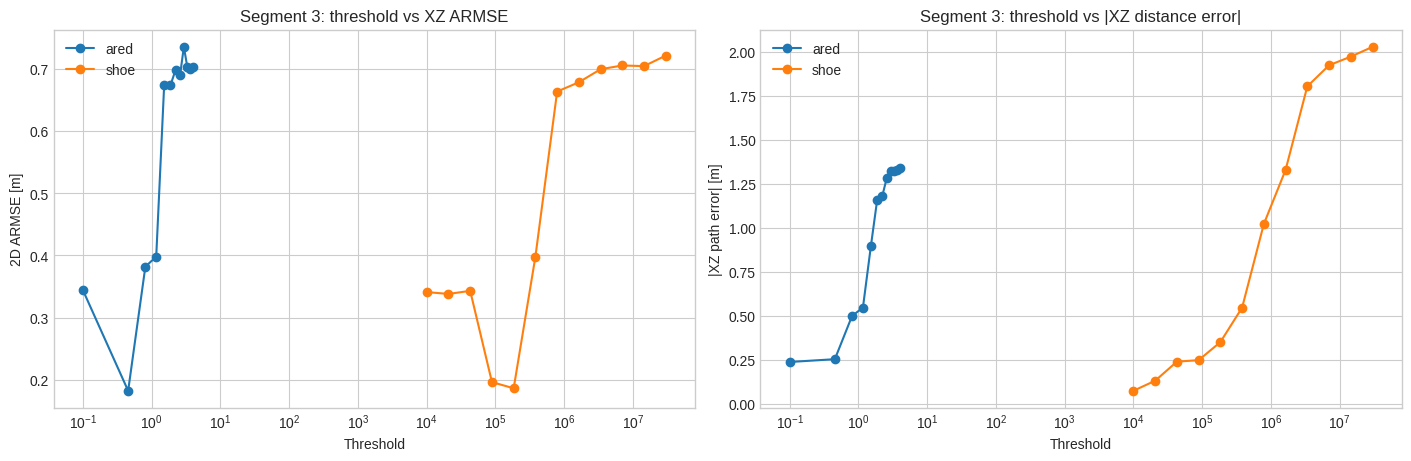

In [6]:
segment_sweep = metrics_df.loc[metrics_df["segment_id"] == SEGMENT_TO_PLOT].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for detector, group in segment_sweep.groupby("detector"):
    group = group.sort_values("threshold")
    axes[0].plot(group["threshold"], group["armse_2d_m"], marker="o", label=detector)
    axes[1].plot(group["threshold"], group["abs_path_xz_error_m"], marker="o", label=detector)

axes[0].set_xscale("log")
axes[0].set_title(f"Segment {SEGMENT_TO_PLOT}: threshold vs XZ ARMSE")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("2D ARMSE [m]")
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_title(f"Segment {SEGMENT_TO_PLOT}: threshold vs |XZ distance error|")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("|XZ path error| [m]")
axes[1].legend()

plt.show()
